In [9]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import trange

DEVICE

In [10]:
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


BEAM PARAMETERS

In [11]:
L  = 1.0
E  = 1.0
I  = 1.0
q0 = 1.0
EI = E * I

TRAINING DATA

In [ ]:
def make_grid(N):
    x = np.linspace(0, 1, N).reshape(-1, 1)
    return torch.tensor(x, dtype=torch.float32, requires_grad=True)

def make_random(N):
    x = np.random.rand(N, 1)
    return torch.tensor(x, dtype=torch.float32, requires_grad=True)

Nx  = 100     # grid points
Nf  = 5000    # random collocation points

Xf1 = make_grid(Nx)   # built once, reused for all warm-up epochs

NEURAL NETWORK

In [13]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_size=1, output_size=1,
                 hidden_size=[50, 50, 50], activation='tanh'):

        super(NeuralNetwork, self).__init__()
        layers = []

        layers.append(nn.Linear(input_size, hidden_size[0]))
        layers.append(nn.Tanh())

        for i in range(len(hidden_size) - 1):
            layers.append(nn.Linear(hidden_size[i], hidden_size[i+1]))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_size[-1], output_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)
    
    
    
def auto_grad(u, x, order=1):
    if order == 1:
        return torch.autograd.grad(
            u, x,
            torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
    return auto_grad(auto_grad(u, x), x, order - 1)

def xavier_init(layer):
    if isinstance(layer, nn.Linear):
        nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)

LOSS FUNCTION

In [ ]:
x_left  = torch.tensor([[0.0]], requires_grad=True).to(device)  # x = 0
x_right = torch.tensor([[L]],   requires_grad=True).to(device)  # x = L

def loss_fn(x, model):

    # ── PDE residual at interior collocation points ──────────────────
    w    = model(x)
    d4w  = auto_grad(w, x, 4)          # 4th derivative of w
    residual = EI * d4w - q0           # should be 0 everywhere
    loss_pde = torch.mean(residual**2)

    # ── Boundary condition 1: w(0) = 0 ──────────────────────────────
    # At the clamped end, deflection must be zero.
    w0       = model(x_left)
    loss_bc1 = w0**2                   # want this = 0

    # ── Boundary condition 2: w'(0) = 0 ─────────────────────────────
    # At the clamped end, slope (rotation) must also be zero.
    dw0      = auto_grad(model(x_left), x_left, 1)
    loss_bc2 = dw0**2                  # want this = 0

    # ── Boundary condition 3: w''(L) = 0 ────────────────────────────
    # At the free end, there is no applied moment, so bending moment = 0.
    # Bending moment M = EI * w''(x), so w''(L) must be 0.
    d2wL     = auto_grad(model(x_right), x_right, 2)
    loss_bc3 = d2wL**2                 # want this = 0

    # ── Boundary condition 4: w'''(L) = 0 ───────────────────────────
    # At the free end, there is no applied shear force, so w'''(L) = 0.
    d3wL     = auto_grad(model(x_right), x_right, 3)
    loss_bc4 = d3wL**2                 # want this = 0

    # ── Total loss ───────────────────────────────────────────────────
    loss = loss_pde + loss_bc1 + loss_bc2 + loss_bc3 + loss_bc4

    return loss, loss_pde.item(), loss_bc1.item(), loss_bc2.item()

MODEL, OPTIMISER, SCHEDULER?

In [15]:
model = NeuralNetwork(hidden_size=[50, 50, 50]).to(device)
model.apply(xavier_init)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=3000, gamma=0.5
)

TRAINING LOOP

In [16]:
epochs    = 10000
n_warmup  = 2000 

model.train()
td = trange(epochs)
training_loss_hist = []

for epoch in td:

    # ── Choose training points for this epoch ───────────────────────
    # FIX 3: Xf1 was rebuilt every epoch — now it is built once above.
    # FIX 4: Warm-up is now 2000 epochs, not 100.
    if epoch < n_warmup:
        x = Xf1.to(device)           # fixed grid — same every warm-up epoch
    else:
        x = make_random(Nf).to(device)  # fresh random points each epoch

    # ── Forward + loss ──────────────────────────────────────────────
    loss, loss_pde, loss_bc1, loss_bc2 = loss_fn(x, model)

    # ── Backward pass ───────────────────────────────────────────────
    # FIX 2: Original had zero_grad() AFTER step(). The correct order is:
    #   zero_grad first  → clear old accumulated gradients
    #   backward         → compute fresh gradients for this epoch
    #   step             → update weights using those fresh gradients
    optimizer.zero_grad()    # ← must be before backward()
    loss.backward()
    optimizer.step()
    scheduler.step()         # FIX 5: update learning rate

    training_loss_hist.append(loss.item())

    td.set_description(
        f"loss={loss.item():.3e} | "
        f"pde={loss_pde:.3e} | "
        f"bc_w0={loss_bc1:.3e} | "
        f"bc_dw0={loss_bc2:.3e}"
    )

loss=1.855e-05 | pde=1.844e-05 | bc_w0=1.007e-11 | bc_dw0=4.437e-08: 100%|██████████| 10000/10000 [09:40<00:00, 17.21it/s]


EVALUATION AND PLOTS


Relative L2 error: 0.1152%


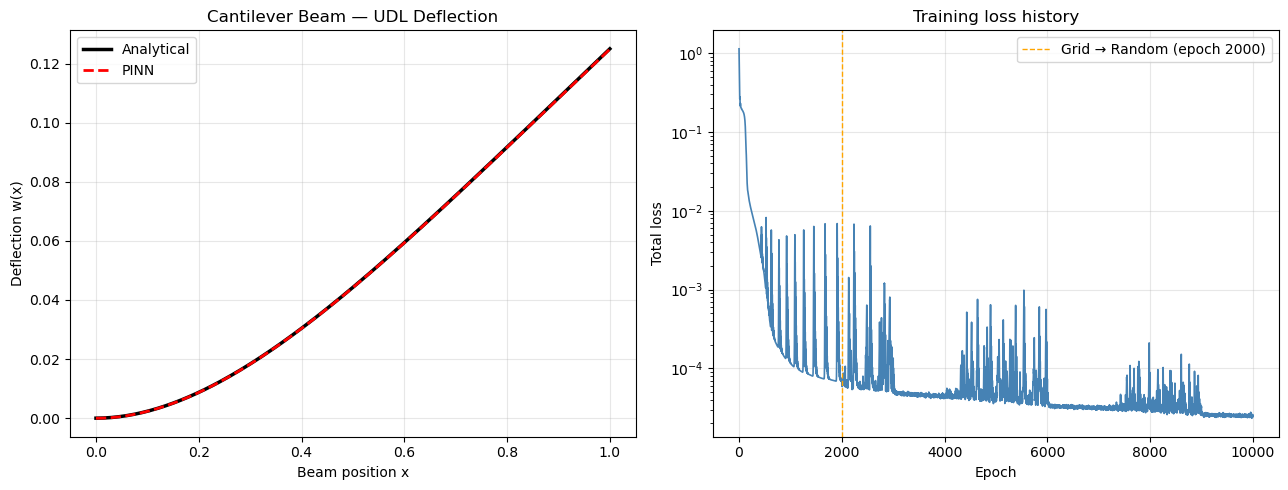

In [10]:
model.eval()

x_test = torch.linspace(0, 1, 200).reshape(-1, 1).to(device)

with torch.no_grad():
    w_pred = model(x_test).detach().cpu().numpy()

x_np   = x_test.cpu().numpy()
w_true = (q0 / (24 * EI)) * x_np**2 * (6*L**2 - 4*L*x_np + x_np**2)

# Relative L2 error — how far off we are as a percentage
rel_error = np.linalg.norm(w_pred - w_true) / np.linalg.norm(w_true)
print(f"\nRelative L2 error: {rel_error * 100:.4f}%")

# ── Plot 1: Deflection comparison ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(x_np, w_true, label="Analytical", linewidth=2.5, color="black")
ax.plot(x_np, w_pred, '--', label="PINN", linewidth=2, color="red")
ax.set_xlabel("Beam position x")
ax.set_ylabel("Deflection w(x)")
ax.set_title("Cantilever Beam — UDL Deflection")
ax.legend()
ax.grid(alpha=0.3)

# ── Plot 2: Loss history ─────────────────────────────────────────────
ax = axes[1]
ax.semilogy(training_loss_hist, linewidth=1.2, color="steelblue")
ax.axvline(x=n_warmup, color="orange", linestyle="--", linewidth=1,
           label=f"Grid → Random (epoch {n_warmup})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Total loss")
ax.set_title("Training loss history")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("udl_pinn_result.png", dpi=150, bbox_inches="tight")
plt.show()

LOADING FEM DATA

In [18]:
import pandas as pd

df = pd.read_csv("cantilever_beam_results.csv")

# x_fem = df["x"].values.reshape(-1, 1)
# w_fem = df["w"].values.reshape(-1, 1)

In [19]:
df.head(20)

,x_m,w_m,theta_rad,M_kNm,V_kN
0,0.000000,0.000000,0.000000,0.500000,-1.000000
1,0.010101,0.000025,0.005000,0.489950,-0.989899
2,0.020202,0.000101,0.009898,0.480002,-0.979798
3,0.030303,0.000225,0.014697,0.470156,-0.969697
4,0.040404,0.000397,0.019397,0.460412,-0.959596
5,0.050505,0.000616,0.023999,0.450770,-0.949495
6,0.060606,0.000882,0.028504,0.441230,-0.939394
7,0.070707,0.001192,0.032913,0.431793,-0.929293
8,0.080808,0.001546,0.037227,0.422457,-0.919192
9,0.090909,0.001944,0.041448,0.413223,-0.909091


In [20]:
x_fem = df['x_m'].values.reshape(-1, 1)
w_fem = df['w_m'].values.reshape(-1,1)

In [21]:
x_fem

array([[0.        ],
       [0.01010101],
       [0.02020202],
       [0.03030303],
       [0.04040404],
       [0.05050505],
       [0.06060606],
       [0.07070707],
       [0.08080808],
       [0.09090909],
       [0.1010101 ],
       [0.11111111],
       [0.12121212],
       [0.13131313],
       [0.14141414],
       [0.15151515],
       [0.16161616],
       [0.17171717],
       [0.18181818],
       [0.19191919],
       [0.2020202 ],
       [0.21212121],
       [0.22222222],
       [0.23232323],
       [0.24242424],
       [0.25252525],
       [0.26262626],
       [0.27272727],
       [0.28282828],
       [0.29292929],
       [0.3030303 ],
       [0.31313131],
       [0.32323232],
       [0.33333333],
       [0.34343434],
       [0.35353535],
       [0.36363636],
       [0.37373737],
       [0.38383838],
       [0.39393939],
       [0.4040404 ],
       [0.41414141],
       [0.42424242],
       [0.43434343],
       [0.44444444],
       [0.45454545],
       [0.46464646],
       [0.474

In [22]:
x_test = torch.tensor(x_fem, dtype=torch.float32, device=device)

In [23]:
with torch.no_grad():
    w_pred = model(x_test).cpu().numpy()

In [24]:
w_pred

array([[1.00187957e-04],
       [1.25221908e-04],
       [2.00428069e-04],
       [3.24599445e-04],
       [4.96722758e-04],
       [7.15784729e-04],
       [9.80891287e-04],
       [1.29095465e-03],
       [1.64533406e-03],
       [2.04242021e-03],
       [2.48192996e-03],
       [2.96268612e-03],
       [3.48379463e-03],
       [4.04403359e-03],
       [4.64306027e-03],
       [5.27951866e-03],
       [5.95302135e-03],
       [6.66209310e-03],
       [7.40621239e-03],
       [8.18463415e-03],
       [8.99636000e-03],
       [9.84062999e-03],
       [1.07163563e-02],
       [1.16231814e-02],
       [1.25599727e-02],
       [1.35259107e-02],
       [1.45206526e-02],
       [1.55430213e-02],
       [1.65923908e-02],
       [1.76680759e-02],
       [1.87691525e-02],
       [1.98949352e-02],
       [2.10451111e-02],
       [2.22184882e-02],
       [2.34144107e-02],
       [2.46325210e-02],
       [2.58719996e-02],
       [2.71318480e-02],
       [2.84120217e-02],
       [2.97113881e-02],


In [25]:
w_fem

array([[0.00000000e+00],
       [2.53362667e-05],
       [1.00663198e-04],
       [2.24965800e-04],
       [3.97239487e-04],
       [6.16490086e-04],
       [8.81733831e-04],
       [1.19199737e-03],
       [1.54631776e-03],
       [1.94374246e-03],
       [2.38332935e-03],
       [2.86414673e-03],
       [3.38527327e-03],
       [3.94579811e-03],
       [4.54482074e-03],
       [5.18145110e-03],
       [5.85480952e-03],
       [6.56402676e-03],
       [7.30824397e-03],
       [8.08661272e-03],
       [8.89829499e-03],
       [9.74246317e-03],
       [1.06183001e-02],
       [1.15249989e-02],
       [1.24617632e-02],
       [1.34278071e-02],
       [1.44223550e-02],
       [1.54446418e-02],
       [1.64939126e-02],
       [1.75694233e-02],
       [1.86704398e-02],
       [1.97962387e-02],
       [2.09461069e-02],
       [2.21193416e-02],
       [2.33152506e-02],
       [2.45331520e-02],
       [2.57723744e-02],
       [2.70322567e-02],
       [2.83121483e-02],
       [2.96114089e-02],


In [29]:
import numpy as np

# RMSE
rmse = np.sqrt(np.mean((w_pred - w_fem)**2))

# MAE
mae = np.mean(np.abs(w_pred - w_fem))

# L2 error (most important)
l2_error = np.linalg.norm(w_pred - w_fem) / np.linalg.norm(w_fem)

# Safe relative error
epsilon = 1e-8
rel_error = np.abs((w_pred - w_fem) / (w_fem + epsilon))
mean_rel_error = np.mean(rel_error)

print("\n--- Accuracy Metrics ---")
print(f"RMSE: {rmse:.6e}")
print(f"MAE: {mae:.6e}")
print(f"L2 Error: {l2_error:.6e}")


--- Accuracy Metrics ---
RMSE: 1.044076e-04
MAE: 1.042381e-04
L2 Error: 1.640466e-03


COMPARING WITH FEM DATA

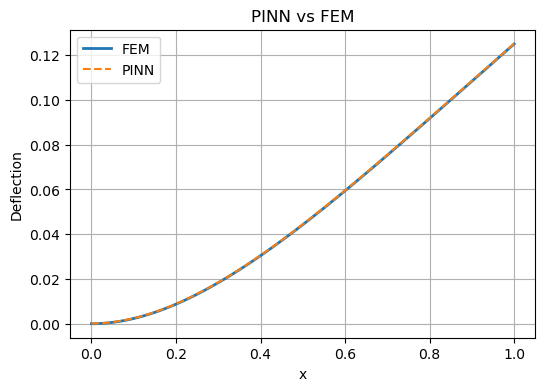

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(x_fem, w_fem, label='FEM', linewidth=2)
plt.plot(x_fem, w_pred, '--', label='PINN')
plt.xlabel("x")
plt.ylabel("Deflection")
plt.title("PINN vs FEM")
plt.legend()
plt.grid()
plt.show()

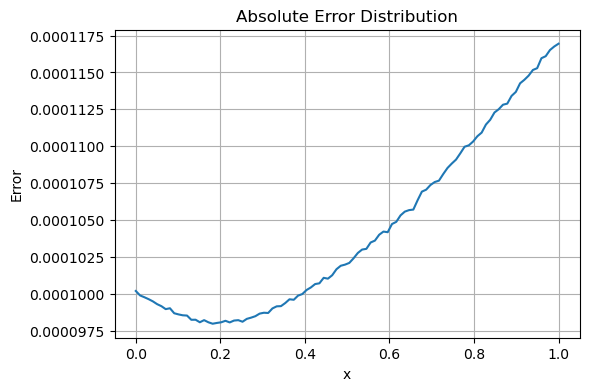

In [28]:
plt.figure(figsize=(6,4))
plt.plot(x_fem, np.abs(w_pred - w_fem))
plt.title("Absolute Error Distribution")
plt.xlabel("x")
plt.ylabel("Error")
plt.grid()
plt.show()